Research Question: How do restaurant inspection results and violations vary across NYC boroughs and over time?

In [52]:
from google.colab import files
uploaded=files.upload()

Saving DOHMH_New_York_City_Restaurant_Inspection_Results_20260430.csv to DOHMH_New_York_City_Restaurant_Inspection_Results_20260430 (1).csv


In [63]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
df=pd.read_csv("DOHMH_New_York_City_Restaurant_Inspection_Results_20260430.csv")
df.head()



,CAMIS,DBA,BORO,BUILDING,STREET,ZIPCODE,PHONE,CUISINE DESCRIPTION,INSPECTION DATE,ACTION,...,INSPECTION TYPE,Latitude,Longitude,Community Board,Council District,Census Tract,BIN,BBL,NTA,Location
0,50182086,877 8TH AVENUE FOOD CORP,Manhattan,877,8 AVENUE,10019.0,2129334120,NaN,01/01/1900,NaN,...,NaN,40.763782,-73.985026,104.0,3.0,13300.0,1025257.0,1.010438e+09,MN15,POINT (-73.9850260269 40.763782325638)
1,50150789,LATOYA'S KITCHEN,Manhattan,2492,ADAM CLAYTON POWELL JR BOULEVARD,NaN,2122346300,Caribbean,09/02/2024,No violations were recorded at the time of thi...,...,Inter-Agency Task Force / Initial Inspection,0.000000,0.000000,NaN,NaN,NaN,NaN,1.000000e+00,NaN,NaN
2,50173648,SUSHI DOKORO MEKUMI,Manhattan,70,CHARLTON STREET,10014.0,2129251613,NaN,01/01/1900,NaN,...,NaN,40.727239,-74.006559,102.0,3.0,3700.0,1090545.0,1.005800e+09,MN24,POINT (-74.006559232767 40.727239355189)
3,50158165,INTERNATIONAL BURGERS,Manhattan,311,EAST 45 STREET,10017.0,2012387005,NaN,01/01/1900,NaN,...,NaN,40.751535,-73.970285,106.0,4.0,9000.0,1038770.0,1.013380e+09,MN19,POINT (-73.970284963875 40.751535084739)
4,50152630,CLOSE UP,Manhattan,154,ORCHARD STREET,10002.0,7036877554,NaN,01/01/1900,NaN,...,NaN,40.720781,-73.988856,103.0,1.0,3001.0,1005344.0,1.004110e+09,MN27,POINT (-73.988856161206 40.720780565274)


In [72]:

print(df.isna().sum())


df = df.dropna(subset=['INSPECTION TYPE']).copy()


df.columns = df.columns.str.strip()


df['INSPECTION DATE'] = pd.to_datetime(df['INSPECTION DATE'])

CAMIS                         0
DBA                           0
BORO                          0
BUILDING                    925
STREET                        0
ZIPCODE                    3059
PHONE                        56
CUISINE DESCRIPTION          96
INSPECTION DATE               0
ACTION                        0
VIOLATION CODE             2360
VIOLATION DESCRIPTION      2360
CRITICAL FLAG                 0
SCORE                     13588
GRADE                    147113
GRADE DATE               156652
RECORD DATE                   0
INSPECTION TYPE               0
Latitude                   1507
Longitude                  1507
Community Board            4541
Council District           4511
Census Tract               4511
BIN                        5710
BBL                        1507
NTA                        4541
Location                   4541
Year                          0
Month                         0
Day of Week                   0
Month Name                    0
dtype: i

            BORO  Violation Count
3      Manhattan           107565
2       Brooklyn            73748
4         Queens            72254
1          Bronx            26681
5  Staten Island             9674
0              0              293


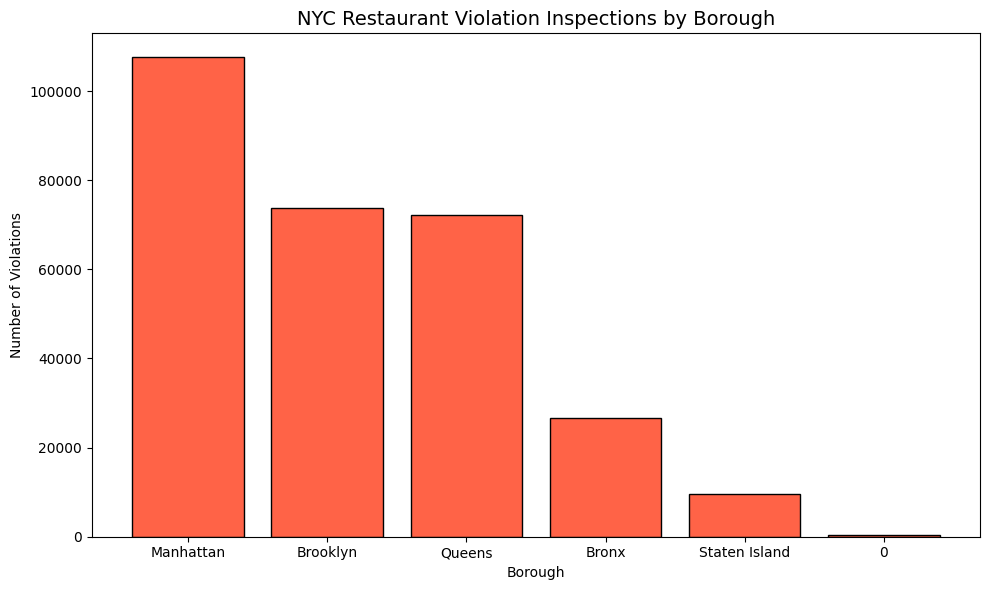

In [73]:


violations = df[df['ACTION'].str.contains('Violations', na=False, case=False)]
borough_violations = violations.groupby('BORO').size().reset_index(name='Violation Count')
borough_violations = borough_violations.sort_values('Violation Count', ascending=False)
print(borough_violations)


plt.figure(figsize=(10, 6))
plt.bar(borough_violations['BORO'], borough_violations['Violation Count'], color='tomato', edgecolor='black')
plt.title('NYC Restaurant Violation Inspections by Borough', fontsize=14)
plt.xlabel('Borough')
plt.ylabel('Number of Violations')
plt.tight_layout()
plt.show()

📅 Inspections by Year:
Year
1900     3473
2007       51
2008       45
2009        4
2010       13
2011        6
2012        6
2013        2
2014       12
2015       33
2016      269
2017      497
2018      768
2019      896
2020      279
2021      695
2022    25467
2023    60278
2024    81961
2025    92230
2026    29755
dtype: int64

📆 Inspections by Month:
Month Name
April        30656
August       22160
December     26178
February     23420
January      29334
July         20767
June         21023
March        30141
May          24394
November     21786
October      25827
September    21054
dtype: int64

📊 Inspections by Day of Week:
Day of Week
Friday       34457
Monday       59237
Saturday      6526
Sunday        1591
Thursday     66055
Tuesday      63674
Wednesday    65200
dtype: int64


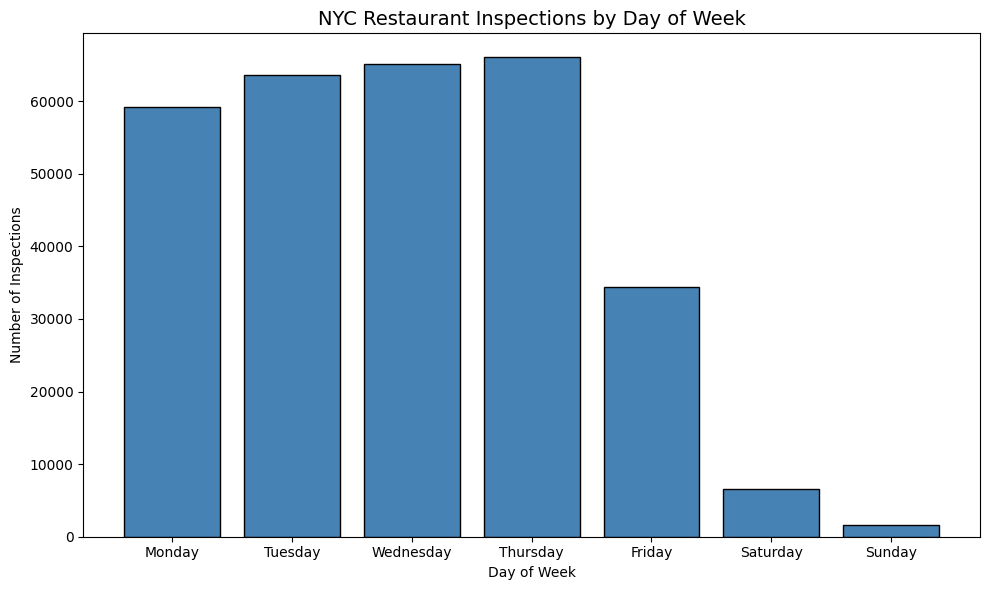

In [65]:



df['INSPECTION DATE'] = pd.to_datetime(df['INSPECTION DATE'], errors='coerce')


df['Year'] = df['INSPECTION DATE'].dt.year
df['Month'] = df['INSPECTION DATE'].dt.month
df['Day of Week'] = df['INSPECTION DATE'].dt.day_name()
df['Month Name'] = df['INSPECTION DATE'].dt.month_name()


print("📅 Inspections by Year:")
print(df.groupby('Year').size().sort_index())


print("\n📆 Inspections by Month:")
print(df.groupby('Month Name').size())


print("\n📊 Inspections by Day of Week:")
print(df.groupby('Day of Week').size())


day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
day_counts = df.groupby('Day of Week').size().reindex(day_order)

plt.figure(figsize=(10, 6))
plt.bar(day_counts.index, day_counts.values, color='steelblue', edgecolor='black')
plt.title('NYC Restaurant Inspections by Day of Week', fontsize=14)
plt.xlabel('Day of Week')
plt.ylabel('Number of Inspections')
plt.tight_layout()
plt.show()

In [76]:
print(df['INSPECTION TYPE'].value_counts())

INSPECTION TYPE
Cycle Inspection / Initial Inspection                            156329
Cycle Inspection / Re-inspection                                  58864
Pre-permit (Operational) / Initial Inspection                     41427
Pre-permit (Operational) / Re-inspection                          10847
Administrative Miscellaneous / Initial Inspection                  9470
Pre-permit (Non-operational) / Initial Inspection                  3688
Cycle Inspection / Reopening Inspection                            2589
Pre-permit (Operational) / Compliance Inspection                   1960
Administrative Miscellaneous / Re-inspection                       1864
Cycle Inspection / Compliance Inspection                           1274
Inter-Agency Task Force / Initial Inspection                        913
Pre-permit (Operational) / Reopening Inspection                     881
Smoke-Free Air Act / Initial Inspection                             699
Pre-permit (Non-operational) / Re-inspection    

In [78]:
inspection_counts = (
df['INSPECTION TYPE']
.value_counts()
.reset_index()
)
inspection_counts.columns = ['INSPECTION TYPE', 'Count']

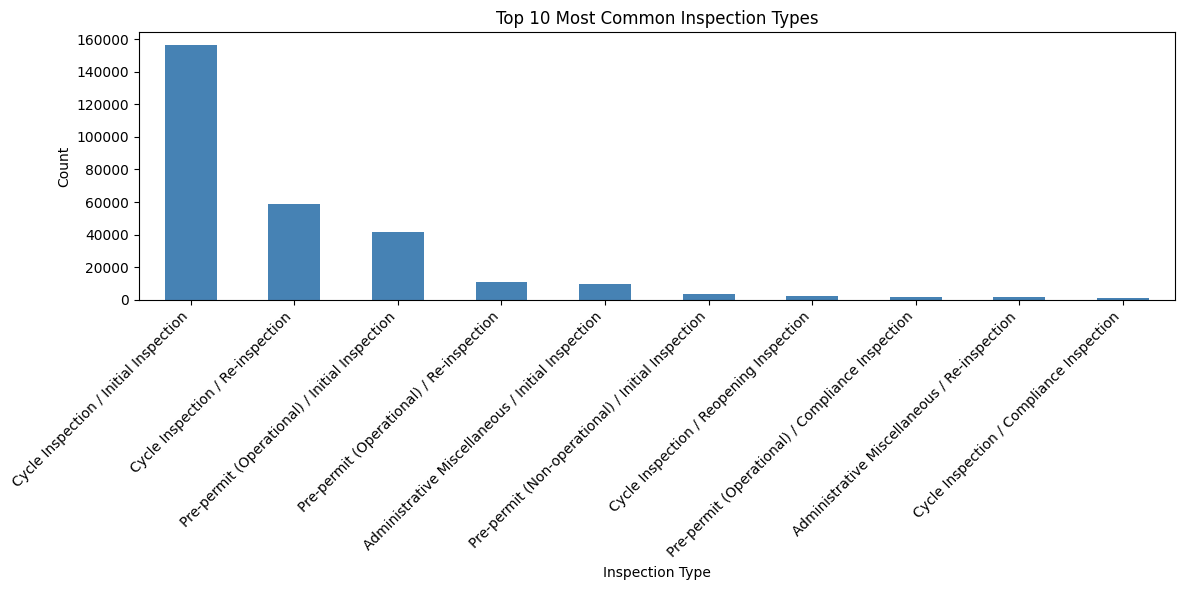

In [77]:
top_10 = df['INSPECTION TYPE'].value_counts().head(10)

plt.figure(figsize=(12, 6))
top_10.plot(kind='bar', color='steelblue')
plt.title('Top 10 Most Common Inspection Types')
plt.xlabel('Inspection Type')
plt.ylabel('Count')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [68]:

top_10 = inspection_counts.head(10)

print("🔍 Top 10 Most Common Inspection Types:")
print(top_10[['INSPECTION TYPE', 'Count']])

🔍 Top 10 Most Common Inspection Types:
                                     INSPECTION TYPE   Count
0              Cycle Inspection / Initial Inspection  156329
1                   Cycle Inspection / Re-inspection   58864
2      Pre-permit (Operational) / Initial Inspection   41427
3           Pre-permit (Operational) / Re-inspection   10847
4  Administrative Miscellaneous / Initial Inspection    9470
5  Pre-permit (Non-operational) / Initial Inspection    3688
6            Cycle Inspection / Reopening Inspection    2589
7   Pre-permit (Operational) / Compliance Inspection    1960
8       Administrative Miscellaneous / Re-inspection    1864
9           Cycle Inspection / Compliance Inspection    1274


In [62]:
op_violations = (
violations
.groupby(['BORO', 'VIOLATION DESCRIPTION'])
.size()
.reset_index(name='Count')
.sort_values('Count', ascending=False)
.groupby('BORO')
.head(3)
.reset_index(drop=True)
)

print(op_violations[['BORO', 'VIOLATION DESCRIPTION', 'Count']])

             BORO                              VIOLATION DESCRIPTION  Count
0       Manhattan  Non-food contact surface or equipment made of ...  14684
1        Brooklyn  Non-food contact surface or equipment made of ...   9446
2          Queens  Non-food contact surface or equipment made of ...   9221
3       Manhattan  Establishment is not free of harborage or cond...   8755
4       Manhattan  Food contact surface not properly washed, rins...   7678
5        Brooklyn  Establishment is not free of harborage or cond...   6522
6          Queens  Establishment is not free of harborage or cond...   6042
7        Brooklyn  Food contact surface not properly washed, rins...   4578
8          Queens  Food, supplies, or equipment not protected fro...   4494
9           Bronx  Non-food contact surface or equipment made of ...   4016
10          Bronx  Establishment is not free of harborage or cond...   2523
11          Bronx  Anti-siphonage or back-flow prevention device ...   1895
12  Staten I

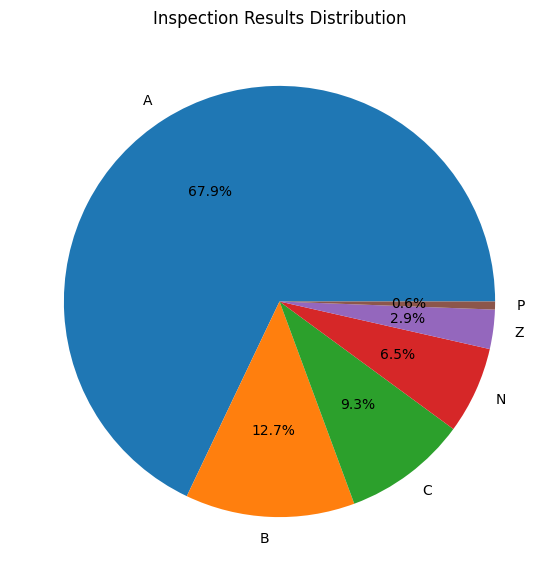

In [80]:
df['GRADE'].value_counts().plot(kind='pie', autopct='%1.1f%%', figsize=(7,7))
plt.title('Inspection Results Distribution')
plt.ylabel('')
plt.show()

In [82]:
result_counts = df['GRADE'].value_counts()
result_pct = df['GRADE'].value_counts(normalize=True) * 100

summary = pd.DataFrame({
'Count': result_counts,
'Percentage': result_pct.round(2)
})

print(summary)

       Count  Percentage
GRADE                   
A      99277       67.93
B      18577       12.71
C      13578        9.29
N       9545        6.53
Z       4300        2.94
P        877        0.60


CONCLUSION: Manhattan, Brooklyn, and Queens have the highest violation counts, and specific violations like "Non-food contact surface or equipment made of..." and "Establishment is not free of harborage or cond..." appear frequently across boroughs. By analyzing the 'GRADE' column, it was determined that the majority of restaurants (67.93%) received an 'A' grade, indicating a generally high level of compliance. 'B' and 'C' grades follow, with 'N', 'Z', and 'P' grades being less common.
